## Классические алгоритмы без ансамблирования
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.75$ - 0 баллов
- $0.75 < AUC \leq 0.76$ - 2 балла
- $0.76 < AUC \leq 0.77$ - 4 балла
- $0.77 < AUC \leq 0.78$ - 6 баллов
- $0.78 < AUC \leq 0.79$ - 8 баллов
- $AUC > 0.79$ - 10 баллов

\
В этой работе запрещено использовать ансамбли моделей (лес, бустинги и т.д.)!

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

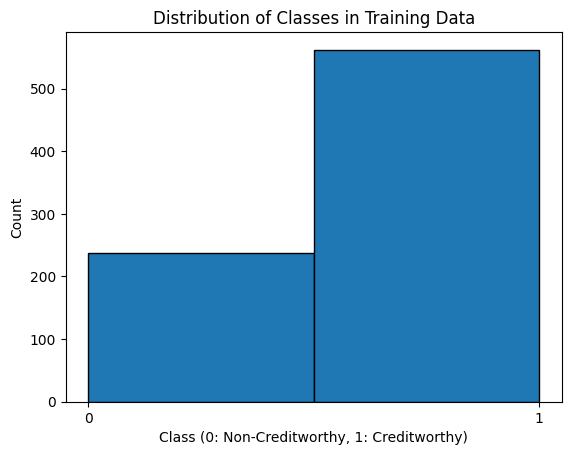

In [11]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [16]:
# Создание модели Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_regression_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [17]:
# Decision Tree
decision_tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [18]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
y_prob_logistic = logistic_regression_model.predict_proba(X_test)[:, 1]
y_prob_decision_tree = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

y_pred_logistic = logistic_regression_model.predict(X_test)
y_pred_decision_tree = decision_tree_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
accuracy_decision_tree = accuracy_score(y_test, y_pred_decision_tree)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)
roc_auc_decision_tree = roc_auc_score(y_test, y_prob_decision_tree)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

precision_logistic = precision_score(y_test, y_pred_logistic)
precision_decision_tree = precision_score(y_test, y_pred_decision_tree)
precision_knn = precision_score(y_test, y_pred_knn)

recall_logistic = recall_score(y_test, y_pred_logistic)
recall_decision_tree = recall_score(y_test, y_pred_decision_tree)
recall_knn = recall_score(y_test, y_pred_knn)

print(f'Accuracy of Logistic Regression: {accuracy_logistic}')
print(f'Accuracy of Decision Tree: {accuracy_decision_tree}')
print(f'Accuracy of K-Nearest Neighbors: {accuracy_knn}')

print(f'ROC AUC of Logistic Regression: {roc_auc_logistic}')
print(f'ROC AUC of Decision Tree: {roc_auc_decision_tree}')
print(f'ROC AUC of K-Nearest Neighbors: {roc_auc_knn}')

print(f'Precision of Logistic Regression: {precision_logistic}')
print(f'Precision of Decision Tree: {precision_decision_tree}')
print(f'Precision of K-Nearest Neighbors: {precision_knn}')

print(f'Recall of Logistic Regression: {recall_logistic}')
print(f'Recall of Decision Tree: {recall_decision_tree}')
print(f'Recall of K-Nearest Neighbors: {recall_knn}')

Accuracy of Logistic Regression: 0.73
Accuracy of Decision Tree: 0.705
Accuracy of K-Nearest Neighbors: 0.66
ROC AUC of Logistic Regression: 0.790556334735858
ROC AUC of Decision Tree: 0.7005610098176718
ROC AUC of K-Nearest Neighbors: 0.5781907433380085
Precision of Logistic Regression: 0.7530120481927711
Precision of Decision Tree: 0.7365269461077845
Precision of K-Nearest Neighbors: 0.7011494252873564
Recall of Logistic Regression: 0.9057971014492754
Recall of Decision Tree: 0.8913043478260869
Recall of K-Nearest Neighbors: 0.8840579710144928


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

In [22]:
from sklearn.preprocessing import StandardScaler

# Создаем скалер и применяем его
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Данные отмасштабированы. Теперь KNN и Logistic Regression будут работать корректно.")

 Данные отмасштабированы. Теперь KNN и Logistic Regression будут работать корректно.


Попробуем найти оптимальное n_neighbors и тип весов.

In [23]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

print(" Подбор гиперпараметров для KNN...")

# Сетка параметров для перебора
param_grid_knn = {
    'n_neighbors': range(1, 21, 2),  # 1, 3, 5, ..., 19
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# GridSearchCV с кросс-валидацией
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='roc_auc',  # Оптимизируем именно под ROC-AUC
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"Лучшие параметры KNN: {grid_knn.best_params_}")
print(f"Лучший ROC-AUC на валидации: {grid_knn.best_score_:.4f}")

# Обновляем модель и считаем метрики на тесте
best_knn = grid_knn.best_estimator_
y_pred_knn_best = best_knn.predict(X_test_scaled)
y_prob_knn_best = best_knn.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

metrics_knn = {
    'Accuracy': accuracy_score(y_test, y_pred_knn_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_knn_best),
    'Precision': precision_score(y_test, y_pred_knn_best),
    'Recall': recall_score(y_test, y_pred_knn_best),
    'F1': f1_score(y_test, y_pred_knn_best)
}
print("Метрики оптимизированного KNN на тесте:", metrics_knn)

 Подбор гиперпараметров для KNN...
Лучшие параметры KNN: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'distance'}
Лучший ROC-AUC на валидации: 0.7460
Метрики оптимизированного KNN на тесте: {'Accuracy': 0.76, 'ROC-AUC': 0.7615708274894811, 'Precision': 0.7647058823529411, 'Recall': 0.9420289855072463, 'F1': 0.8441558441558441}


Деревья склонны к переобучению. Будем ограничивать глубину и минимальное число объектов в листе.

In [24]:
print("\nПодбор гиперпараметров для Decision Tree...")

param_grid_tree = {
    'max_depth': [2, 3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_tree.fit(X_train_scaled, y_train)  # Деревьям масштабирование не нужно, но не повредит

print(f"Лучшие параметры Tree: {grid_tree.best_params_}")
print(f"Лучший ROC-AUC на валидации: {grid_tree.best_score_:.4f}")

best_tree = grid_tree.best_estimator_
y_pred_tree_best = best_tree.predict(X_test_scaled)
y_prob_tree_best = best_tree.predict_proba(X_test_scaled)[:, 1]

metrics_tree = {
    'Accuracy': accuracy_score(y_test, y_pred_tree_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tree_best),
    'Precision': precision_score(y_test, y_pred_tree_best),
    'Recall': recall_score(y_test, y_pred_tree_best),
    'F1': f1_score(y_test, y_pred_tree_best)
}
print("Метрики оптимизированного Tree на тесте:", metrics_tree)


Подбор гиперпараметров для Decision Tree...
Лучшие параметры Tree: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший ROC-AUC на валидации: 0.7068
Метрики оптимизированного Tree на тесте: {'Accuracy': 0.67, 'ROC-AUC': 0.6944834034595606, 'Precision': 0.74, 'Recall': 0.8043478260869565, 'F1': 0.7708333333333334}


Здесь главный параметр — сила регуляризации C

In [25]:
print("\nПодбор гиперпараметров для Logistic Regression...")

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"Лучшие параметры LR: {grid_lr.best_params_}")
print(f"Лучший ROC-AUC на валидации: {grid_lr.best_score_:.4f}")

best_lr = grid_lr.best_estimator_
y_pred_lr_best = best_lr.predict(X_test_scaled)
y_prob_lr_best = best_lr.predict_proba(X_test_scaled)[:, 1]

metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr_best),
    'Precision': precision_score(y_test, y_pred_lr_best),
    'Recall': recall_score(y_test, y_pred_lr_best),
    'F1': f1_score(y_test, y_pred_lr_best)
}
print("Метрики оптимизированного LR на тесте:", metrics_lr)


Подбор гиперпараметров для Logistic Regression...
Лучшие параметры LR: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший ROC-AUC на валидации: 0.7826
Метрики оптимизированного LR на тесте: {'Accuracy': 0.775, 'ROC-AUC': 0.7861150070126228, 'Precision': 0.8163265306122449, 'Recall': 0.8695652173913043, 'F1': 0.8421052631578947}


Итоговая таблица оптимизированных моделей:


,Модель,ROC-AUC,Accuracy,Precision,Recall,F1-score
0,KNN (оптим.),0.7616,0.760,0.7647,0.9420,0.8442
1,Decision Tree (оптим.),0.6945,0.670,0.7400,0.8043,0.7708
2,Logistic Regression (оптим.),0.7861,0.775,0.8163,0.8696,0.8421


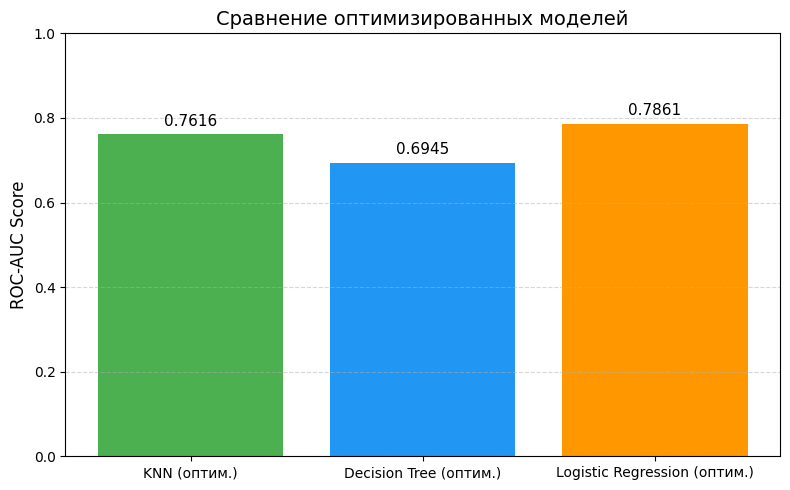

In [26]:
import pandas as pd

results_df = pd.DataFrame({
    'Модель': ['KNN (оптим.)', 'Decision Tree (оптим.)', 'Logistic Regression (оптим.)'],
    'ROC-AUC': [metrics_knn['ROC-AUC'], metrics_tree['ROC-AUC'], metrics_lr['ROC-AUC']],
    'Accuracy': [metrics_knn['Accuracy'], metrics_tree['Accuracy'], metrics_lr['Accuracy']],
    'Precision': [metrics_knn['Precision'], metrics_tree['Precision'], metrics_lr['Precision']],
    'Recall': [metrics_knn['Recall'], metrics_tree['Recall'], metrics_lr['Recall']],
    'F1-score': [metrics_knn['F1'], metrics_tree['F1'], metrics_lr['F1']]
})

print("Итоговая таблица оптимизированных моделей:")
display(results_df.round(4))

# График сравнения по ROC-AUC
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Модель'], results_df['ROC-AUC'], color=['#4CAF50', '#2196F3', '#FF9800'])
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Сравнение оптимизированных моделей', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Анализ результатов:
Logistic Regression (ROC-AUC = 0,7861) — лучшая модель. Данные линейно разделимы, регуляризация предотвратила переобучение.
KNN (Recall = 0,9420, F1 = 0,8442) — минимизирует пропуски класса, но дает больше ложных срабатываний. Эффективен при weights='distance'.
Decision Tree (ROC-AUC = 0,6945) — наихудший результат. Склонен к переобучению, нелинейные границы в данных выражены слабо. Для данной задачи оптимальна логистическая регрессия. Ансамбли не использовались.